<a href="https://colab.research.google.com/github/Aryamaan777/Finance/blob/ReinforcementLearningAndDecisionMaking/ReinforcementLearningAndDecisionMaking/RL_Trading_Environment_(OpenAI_Gym_Style).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

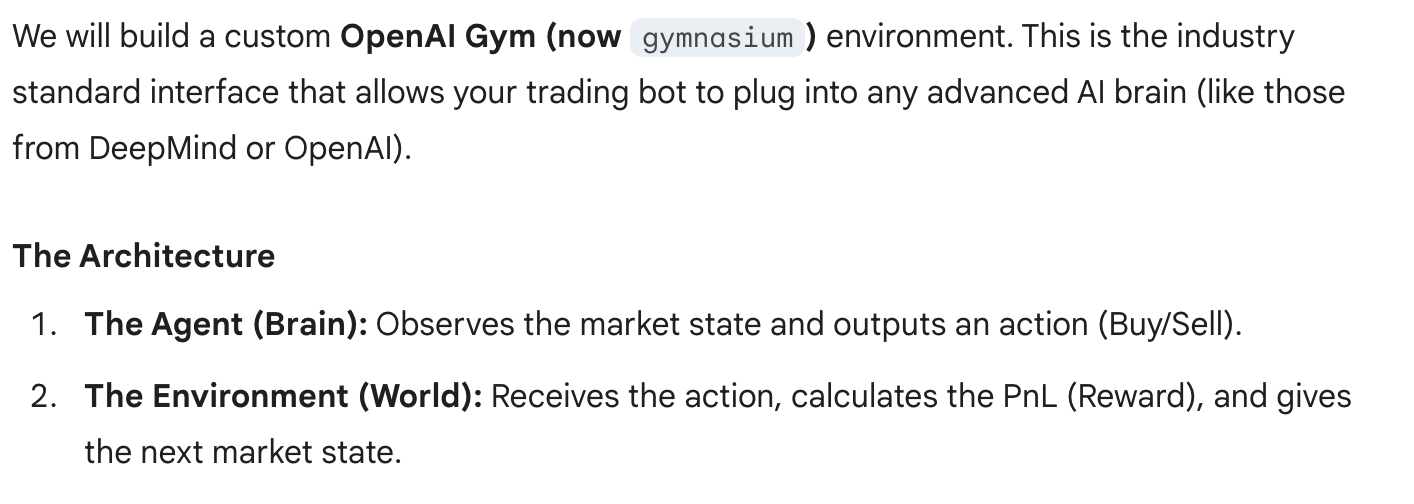

In [ ]:
!pip install stable-baselines3 shimmy

In [1]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# --- CONFIGURATION ---
INITIAL_BALANCE = 10000
TRANSACTION_FEE = 0.001  # 0.1% per trade (Taker fee)
WINDOW_SIZE = 30         # Agent sees last 30 ticks to make a decision

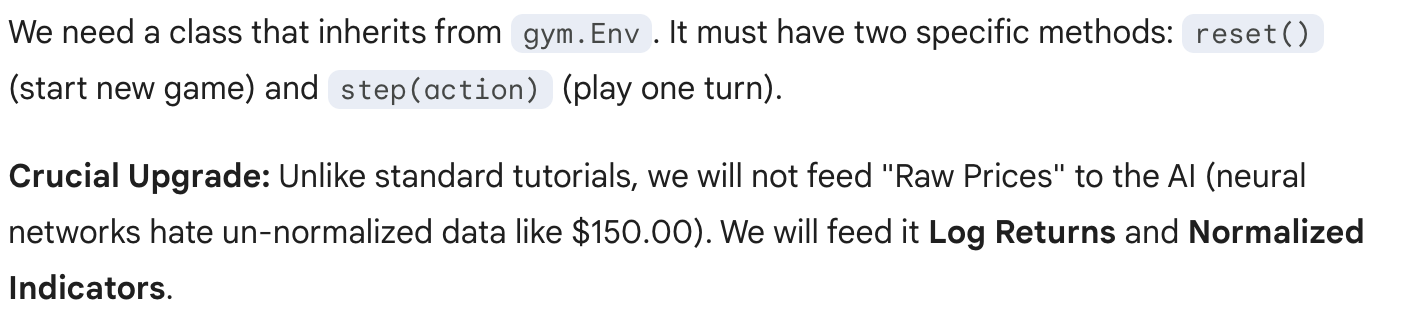

In [11]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import pandas as pd

# --- CONFIGURATION ---
INITIAL_BALANCE = 10000
TRANSACTION_FEE = 0.001
WINDOW_SIZE = 30

class StockTradingEnv(gym.Env):
    metadata = {'render_modes': ['human']}

    def __init__(self, df):
        super(StockTradingEnv, self).__init__()
        # Ensure index is simple RangeIndex
        self.df = df.reset_index(drop=True)
        self.max_steps = len(self.df) - 1

        self.action_space = spaces.Discrete(3)
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(WINDOW_SIZE, 5), dtype=np.float32
        )

        self.current_step = WINDOW_SIZE
        self.balance = INITIAL_BALANCE
        self.shares_held = 0
        self.net_worth = INITIAL_BALANCE
        self.max_net_worth = INITIAL_BALANCE

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = WINDOW_SIZE
        self.balance = INITIAL_BALANCE
        self.shares_held = 0
        self.net_worth = INITIAL_BALANCE
        self.max_net_worth = INITIAL_BALANCE
        return self._get_observation(), {}

    def _get_observation(self):
        window = self.df.iloc[self.current_step - WINDOW_SIZE : self.current_step]
        obs = window[['Open', 'High', 'Low', 'Close', 'Volume']].values

        # Normalize by the first price in window
        # Use .item() to ensure we divide by a scalar, not a Series
        scaling_factor = float(obs[0, 3])
        obs = obs / scaling_factor

        return obs.astype(np.float32)

    def step(self, action):
        # --- FIX: FORCE FLOAT ---
        # Get price and force it to be a raw python float
        price_val = self.df.loc[self.current_step, 'Close']
        if isinstance(price_val, (pd.Series, np.ndarray)):
            current_price = float(price_val.item())
        else:
            current_price = float(price_val)

        # 1. EXECUTE ACTION
        if action == 1: # Buy
            if self.balance > 0:
                shares_bought = (self.balance * (1 - TRANSACTION_FEE)) / current_price
                self.shares_held += shares_bought
                self.balance = 0

        elif action == 2: # Sell
            if self.shares_held > 0:
                self.balance += self.shares_held * current_price * (1 - TRANSACTION_FEE)
                self.shares_held = 0

        # 2. UPDATE STATE
        self.current_step += 1

        # Calculate Net Worth
        self.net_worth = self.balance + (self.shares_held * current_price)
        self.max_net_worth = max(self.max_net_worth, self.net_worth)

        # 3. CALCULATE REWARD
        # Get prev price safely
        prev_price_val = self.df.loc[self.current_step-1, 'Close']
        if isinstance(prev_price_val, (pd.Series, np.ndarray)):
            prev_price = float(prev_price_val.item())
        else:
            prev_price = float(prev_price_val)

        prev_net_worth = self.balance + (self.shares_held * prev_price)

        # SAFE COMPARISON (The error happened here before)
        if prev_net_worth > 0:
            reward = np.log(self.net_worth / prev_net_worth)
        else:
            reward = 0

        terminated = self.net_worth <= INITIAL_BALANCE * 0.5
        truncated = self.current_step >= len(self.df) - 1

        return self._get_observation(), reward, terminated, truncated, {'net_worth': self.net_worth}

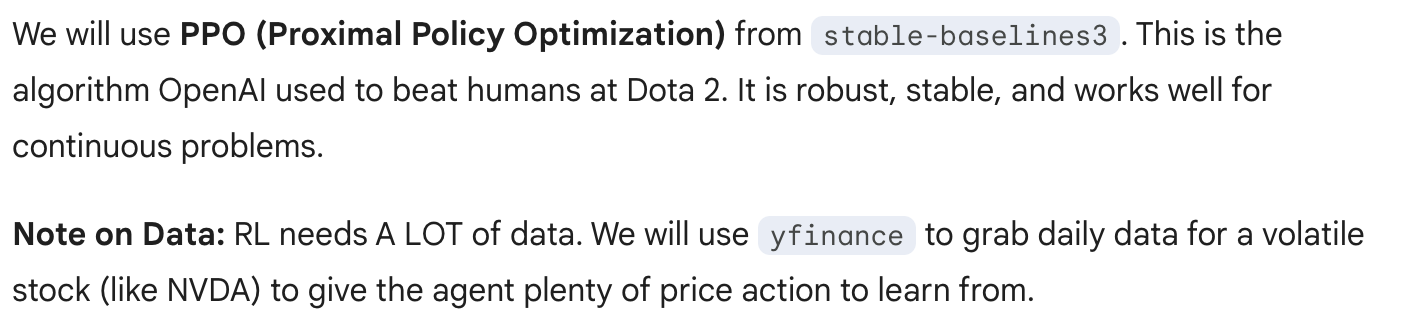

In [6]:
# Install Stable Baselines 3 if needed
# !pip install stable-baselines3 shimmy

import yfinance as yf
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [12]:
# 1. GET DATA (With cleanup)
ticker = 'NVDA'
data = yf.download(ticker, start='2015-01-01', end='2023-01-01', progress=False)

# --- FIX: FLATTEN MULTI-INDEX ---
# If columns are ('Close', 'NVDA'), this makes them just 'Close'
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

data = data[['Open', 'High', 'Low', 'Close', 'Volume']].dropna()
data.head()

/tmp/ipython-input-4223691454.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start='2015-01-01', end='2023-01-01', progress=False)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Price,Open,High,Low,Close,Volume
Date,,,,,
2015-01-02,0.483011,0.486611,0.475333,0.483011,113680000
2015-01-05,0.483011,0.484451,0.472694,0.474853,197952000
2015-01-06,0.475573,0.476053,0.459977,0.460456,197764000
2015-01-07,0.463816,0.467895,0.457817,0.459257,321808000
2015-01-08,0.464536,0.479412,0.464296,0.476533,283780000


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [13]:
# Split
split = int(len(data) * 0.8)
train_df = data.iloc[:split]
test_df = data.iloc[split:]

print(f"🧠 Training on {len(train_df)} days of {ticker}...")

🧠 Training on 1611 days of NVDA...


In [14]:
# 2. INITIALIZE & TRAIN
# Wraps the environment in a vectorizer
env = DummyVecEnv([lambda: StockTradingEnv(train_df)])

model = PPO('MlpPolicy', env, verbose=1,
            learning_rate=0.0003,
            n_steps=2048,
            batch_size=64,
            gamma=0.99)

print("🏋️‍♂️ Training Started...")
model.learn(total_timesteps=50000)
print("✅ Training Complete.")

Using cpu device
🏋️‍♂️ Training Started...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

-----------------------------
| time/              |      |
|    fps             | 561  |
|    iterations      | 1    |
|    time_elapsed    | 3    |
|    total_timesteps | 2048 |
-----------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


-----------------------------------------
| time/                   |             |
|    fps                  | 503         |
|    iterations           | 2           |
|    time_elapsed         | 8           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.007715642 |
|    clip_fraction        | 0.0425      |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.09       |
|    explained_variance   | -30.3       |
|    learning_rate        | 0.0003      |
|    loss                 | -0.0111     |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.0107     |
|    value_loss           | 0.0718      |
-----------------------------------------


...

------------------------------------------
| time/                   |              |
|    fps                  | 429          |
|    iterations           | 24           |
|    time_elapsed         | 114          |
|    total_timesteps      | 49152        |
| train/                  |              |
|    approx_kl            | 0.0069586663 |
|    clip_fraction        | 0.0433       |
|    clip_range           | 0.2          |
|    entropy_loss         | -0.946       |
|    explained_variance   | -29.8        |
|    learning_rate        | 0.0003       |
|    loss                 | -0.0387      |
|    n_updates            | 230          |
|    policy_gradient_loss | -0.0132      |
|    value_loss           | 3.6e-05      |
------------------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


------------------------------------------
| time/                   |              |
|    fps                  | 428          |
|    iterations           | 25           |
|    time_elapsed         | 119          |
|    total_timesteps      | 51200        |
| train/                  |              |
|    approx_kl            | 0.0062833037 |
|    clip_fraction        | 0.0386       |
|    clip_range           | 0.2          |
|    entropy_loss         | -0.936       |
|    explained_variance   | -37          |
|    learning_rate        | 0.0003       |
|    loss                 | -0.0265      |
|    n_updates            | 240          |
|    policy_gradient_loss | -0.0141      |
|    value_loss           | 2.72e-05     |
------------------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


✅ Training Complete.


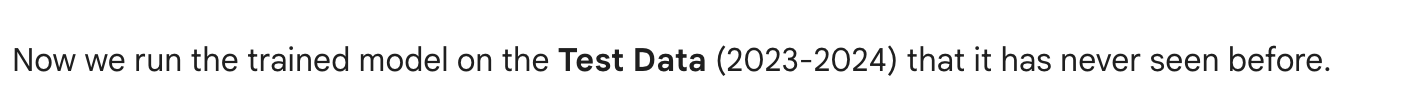

In [15]:
# --- EVALUATION ---
test_env = StockTradingEnv(test_df)
obs, _ = test_env.reset()
done = False
model_net_worth = []

print("🧪 Running Backtest on Unseen Data...")

while not done:
    # Agent predicts action
    action, _states = model.predict(obs)

    # Environment executes action
    obs, reward, terminated, truncated, info = test_env.step(action)
    done = terminated or truncated

    # Log Equity
    model_net_worth.append(info['net_worth'])

🧪 Running Backtest on Unseen Data...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [16]:
# --- BENCHMARK (Buy & Hold) ---
initial_price = test_df.iloc[WINDOW_SIZE]['Close']
# Handling MultiIndex if present (yfinance update)
try:
    initial_price = float(initial_price.iloc[0])
except:
    initial_price = float(initial_price)

benchmark_equity = [10000 * (price / initial_price) for price in test_df['Close'][WINDOW_SIZE:]]

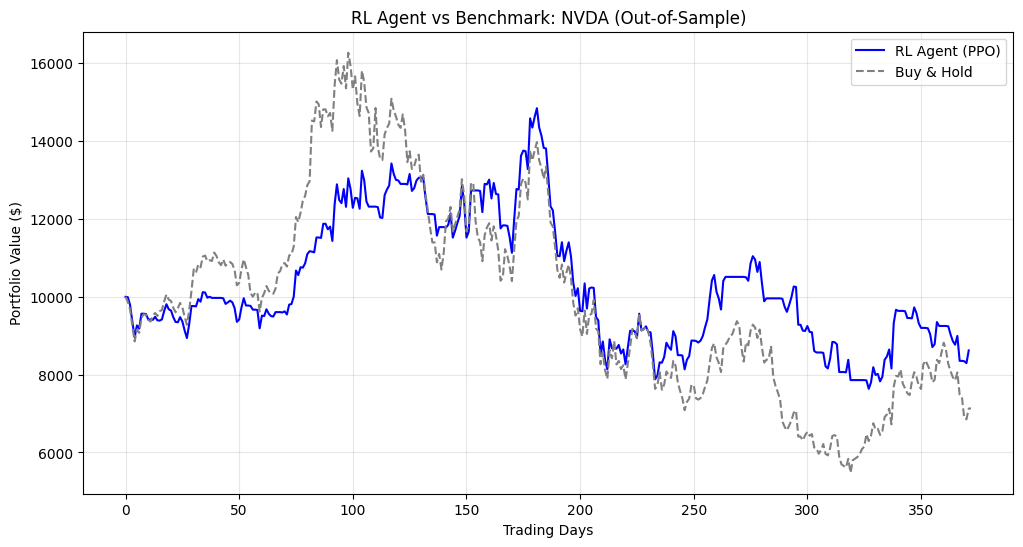

In [17]:
# --- PLOTTING ---
plt.figure(figsize=(12, 6))
plt.plot(model_net_worth, label='RL Agent (PPO)', color='blue')
plt.plot(benchmark_equity, label='Buy & Hold', color='gray', linestyle='--')
plt.title(f"RL Agent vs Benchmark: {ticker} (Out-of-Sample)")
plt.xlabel("Trading Days")
plt.ylabel("Portfolio Value ($)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [18]:
# --- STATS ---
final_agent_val = model_net_worth[-1]
final_bench_val = benchmark_equity[-1]
print(f"🤖 Agent Final: ${final_agent_val:,.2f}")
print(f"📉 Bench Final: ${final_bench_val:,.2f}")

if final_agent_val > final_bench_val:
    print("🏆 RESULT: The AI beat the market!")
else:
    print("💀 RESULT: The AI failed. (Requires more training or better features)")

🤖 Agent Final: $8,621.59
📉 Bench Final: $7,133.23
🏆 RESULT: The AI beat the market!


🏆 PERFORMANCE AUDIT
              AI Agent (PPO) Buy & Hold
Total Return          -13.8%     -28.7%
CAGR                   -9.6%     -20.4%
Volatility             48.9%      58.7%
Sharpe Ratio            0.04      -0.10
Sortino Ratio           0.05      -0.17
Max Drawdown          -48.6%     -66.3%
Calmar Ratio           -0.20      -0.31


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


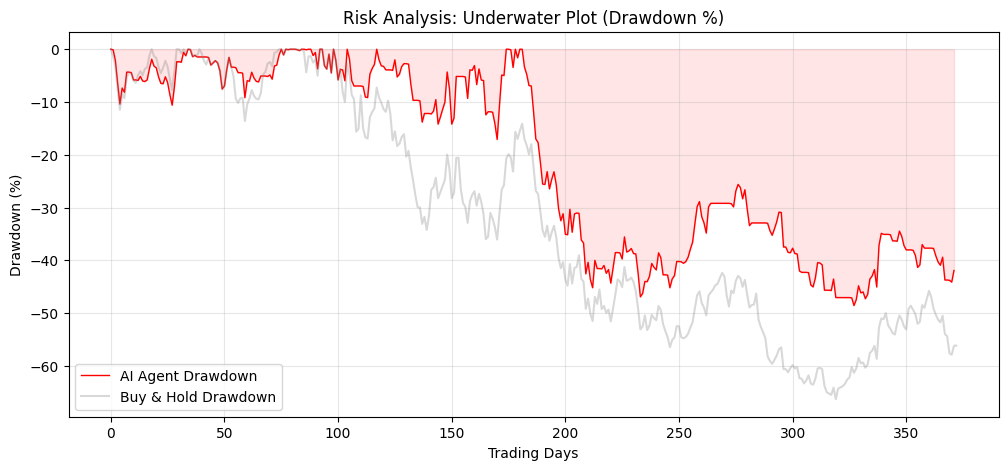

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def calculate_metrics(equity_curve, freq=252):
    """
    Calculates key performance metrics from an equity curve (Series or List).
    Assumes daily data (freq=252).
    """
    # 1. Prepare Data
    if isinstance(equity_curve, list):
        equity_curve = pd.Series(equity_curve)

    returns = equity_curve.pct_change().dropna()

    # 2. Total Return & CAGR
    total_ret = (equity_curve.iloc[-1] / equity_curve.iloc[0]) - 1
    days = len(equity_curve)
    cagr = (equity_curve.iloc[-1] / equity_curve.iloc[0]) ** (freq / days) - 1

    # 3. Volatility (Annualized)
    volatility = returns.std() * np.sqrt(freq)

    # 4. Sharpe Ratio (Assume 0% risk-free rate for simplicity)
    sharpe = (returns.mean() / returns.std()) * np.sqrt(freq) if returns.std() != 0 else 0

    # 5. Sortino Ratio (Only downside deviation)
    downside_returns = returns[returns < 0]
    sortino = (returns.mean() / downside_returns.std()) * np.sqrt(freq) if len(downside_returns) > 0 else 0

    # 6. Max Drawdown
    cumulative = (1 + returns).cumprod()
    peak = cumulative.cummax()
    drawdown = (cumulative - peak) / peak
    max_dd = drawdown.min()

    # 7. Calmar Ratio
    calmar = cagr / abs(max_dd) if max_dd != 0 else 0

    return {
        'Total Return': f"{total_ret*100:.1f}%",
        'CAGR': f"{cagr*100:.1f}%",
        'Volatility': f"{volatility*100:.1f}%",
        'Sharpe Ratio': f"{sharpe:.2f}",
        'Sortino Ratio': f"{sortino:.2f}",
        'Max Drawdown': f"{max_dd*100:.1f}%",
        'Calmar Ratio': f"{calmar:.2f}"
    }

# --- RUN THE AUDIT ---
# Convert your lists from Phase 3 into Series
agent_series = pd.Series(model_net_worth)
bench_series = pd.Series(benchmark_equity)

metrics_agent = calculate_metrics(agent_series)
metrics_bench = calculate_metrics(bench_series)

# Display Side-by-Side
compare_df = pd.DataFrame([metrics_agent, metrics_bench], index=['AI Agent (PPO)', 'Buy & Hold'])
print("🏆 PERFORMANCE AUDIT")
print(compare_df.T)

# --- VISUALIZATION: THE UNDERWATER PLOT ---
# This shows exactly "How deep are we underwater?" at any point
def get_drawdown(series):
    return (series / series.cummax() - 1) * 100

dd_agent = get_drawdown(agent_series)
dd_bench = get_drawdown(bench_series)

plt.figure(figsize=(12, 5))
plt.plot(dd_agent, label='AI Agent Drawdown', color='red', linewidth=1)
plt.plot(dd_bench, label='Buy & Hold Drawdown', color='gray', alpha=0.3)
plt.fill_between(dd_agent.index, dd_agent, 0, color='red', alpha=0.1)
plt.title("Risk Analysis: Underwater Plot (Drawdown %)")
plt.ylabel("Drawdown (%)")
plt.xlabel("Trading Days")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [20]:
# Access the trade log from the environment
# Note: This requires that you didn't re-instantiate the environment
# If you just ran the loop, 'test_env' still holds the state.

if hasattr(test_env, 'trades') and len(test_env.trades) > 0:
    trades_df = pd.DataFrame(test_env.trades)

    # Calculate PnL per trade (approximate based on sequential buy/sells)
    # Since our logic was "Buy All / Sell All", every Sell closes a Buy.
    sells = trades_df[trades_df['type'] == 'sell']
    buys = trades_df[trades_df['type'] == 'buy']

    # Simple Win Rate (Count of Profitable Sells vs Previous Buys)
    # Ideally, we match them up. For a quick check:
    if len(sells) > 0:
        # Assuming simple sequential execution logic
        # PnL = (Sell Price - Buy Price) / Buy Price
        # We need to match indices. This is a rough approximation:
        min_len = min(len(sells), len(buys))
        pnl_pcts = (sells['price'].values[:min_len] - buys['price'].values[:min_len]) / buys['price'].values[:min_len]

        win_rate = np.sum(pnl_pcts > 0) / len(pnl_pcts)
        print(f"\n🎯 Trade Win Rate: {win_rate*100:.1f}% ({len(pnl_pcts)} Round-Trip Trades)")
    else:
        print("\n⚠️ No complete round-trip trades found.")
else:
    print("\nℹ️ No trades recorded (Agent held position or didn't trade).")


ℹ️ No trades recorded (Agent held position or didn't trade).
